In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchsummary import summary
import cv2
import matplotlib.pyplot as plt
import os
import numpy as np

if torch.cuda.is_available():
	print("PyTorch is using the GPU")
	GPUCount = torch.cuda.device_count()
	print(f"Found {GPUCount} GPUs")

	for i in range(GPUCount):
		print(f"GPU {i} found: {torch.cuda.get_device_name(i)}")

	device = torch.device("cuda:0")
else:
	print("PyTorch is using the CPU")
	device = torch.device("cpu")

print(f"Selected Device: {device}")

PyTorch is using the GPU
Found 1 GPUs
GPU 0 found: NVIDIA GeForce RTX 5070 Laptop GPU
Selected Device: cuda:0


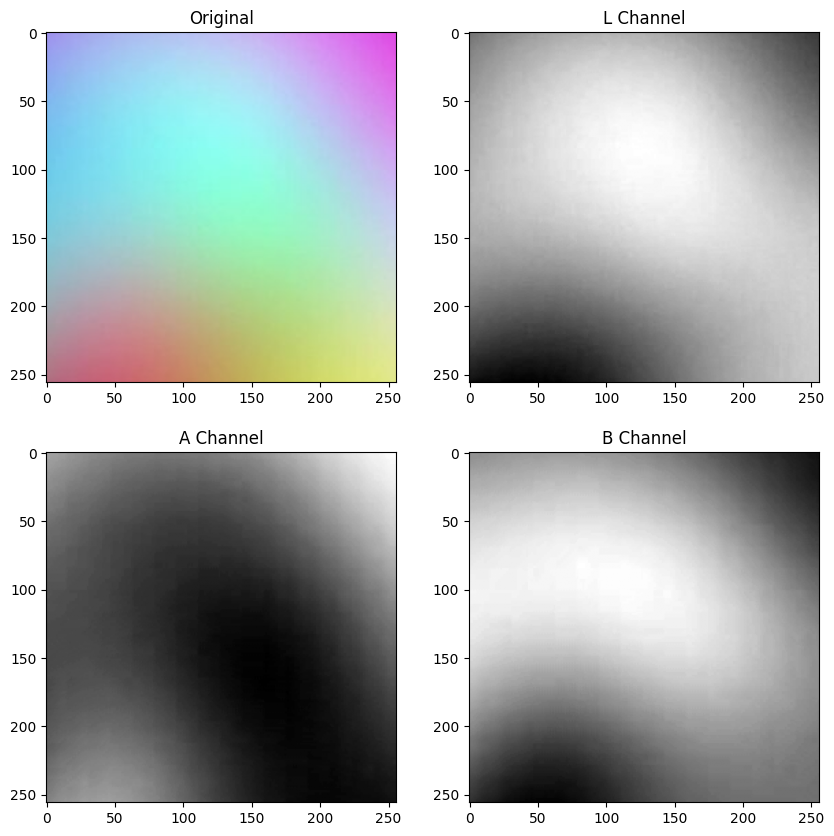

In [6]:
InputImg = cv2.imread('Test.png')
LABImg = cv2.cvtColor(InputImg,cv2.COLOR_RGB2LAB)

plt.figure(figsize=(10,10))
plt.subplot(2,2,1)
plt.title('Original')
plt.imshow(cv2.cvtColor(InputImg,cv2.COLOR_BGR2RGB))
plt.subplot(2,2,2)
plt.title('L Channel')
plt.imshow(LABImg[:,:,0],cmap='gray') #L
plt.subplot(2,2,3)
plt.title('A Channel')
plt.imshow(LABImg[:,:,1],cmap='gray') #A
plt.subplot(2,2,4)
plt.title('B Channel')
plt.imshow(LABImg[:,:,2],cmap='gray') #B

In [7]:
class PrismModel(nn.Module):
	def __init__(self):
		super().__init__()

		self.DownBlock1 = nn.Sequential(
			nn.Conv2d(in_channels=1,out_channels=64,kernel_size=(3,3),padding=1),
			nn.BatchNorm2d(64),
			nn.SiLU(),
			nn.Conv2d(in_channels=64,out_channels=64,kernel_size=(3,3),padding=1),
			nn.BatchNorm2d(64),
			nn.SiLU()
		)
		self.DownBlock2 = nn.Sequential(
			nn.Conv2d(in_channels=64,out_channels=128,kernel_size=(3,3),padding=1),
			nn.BatchNorm2d(128),
			nn.SiLU(),
			nn.Conv2d(in_channels=128,out_channels=128,kernel_size=(3,3),padding=1),
			nn.BatchNorm2d(128),
			nn.SiLU()
		)
		self.DownBlock3 = nn.Sequential(
			nn.Conv2d(in_channels=128,out_channels=256,kernel_size=(3,3),padding=1),
			nn.BatchNorm2d(256),
			nn.SiLU(),
			nn.Conv2d(in_channels=256,out_channels=256,kernel_size=(3,3),padding=1),
			nn.BatchNorm2d(256),
			nn.SiLU()
		)
		self.DownBlock4 = nn.Sequential(
			nn.Conv2d(in_channels=256,out_channels=512,kernel_size=(3,3),padding=1),
			nn.BatchNorm2d(512),
			nn.SiLU(),
			nn.Conv2d(in_channels=512,out_channels=512,kernel_size=(3,3),padding=1),
			nn.BatchNorm2d(512),
			nn.SiLU()
		)
		self.UpBlock1 = nn.Sequential(
			nn.Conv2d(in_channels=768,out_channels=256,kernel_size=(3,3),padding=1),
			nn.BatchNorm2d(256),
			nn.SiLU(),
			nn.Conv2d(in_channels=256,out_channels=256,kernel_size=(3,3),padding=1),
			nn.BatchNorm2d(256),
			nn.SiLU()
		)
		self.UpBlock2 = nn.Sequential(
			nn.Conv2d(in_channels=384,out_channels=128,kernel_size=(3,3),padding=1),
			nn.BatchNorm2d(128),
			nn.SiLU(),
			nn.Conv2d(in_channels=128,out_channels=128,kernel_size=(3,3),padding=1),
			nn.BatchNorm2d(128),
			nn.SiLU()
		)
		self.UpBlock3 = nn.Sequential(
			nn.Conv2d(in_channels=192,out_channels=64,kernel_size=(3,3),padding=1),
			nn.BatchNorm2d(64),
			nn.SiLU(),
			nn.Conv2d(in_channels=64,out_channels=64,kernel_size=(3,3),padding=1),
			nn.BatchNorm2d(64),
			nn.SiLU()
		)
		self.UpConv4 = nn.Conv2d(in_channels=64,out_channels=2,kernel_size=(3,3),padding=1)
		self.MaxPool1 = nn.MaxPool2d((2,2))
		self.UpSample1 = nn.Upsample(scale_factor=2,mode='bilinear')
		self.silu = nn.SiLU()

	def forward(self,x):
		x1 = self.DownBlock1(x)
		x2 = self.MaxPool1(x1)
		x2 = self.DownBlock2(x2)
		x3 = self.MaxPool1(x2)
		x3 = self.DownBlock3(x3)
		x4 = self.MaxPool1(x3)
		x4 = self.DownBlock4(x4)
		x4 = self.UpSample1(x4)
		x3 = self.UpBlock1(torch.cat((x4,x3),dim=1))
		x3 = self.UpSample1(x3)
		x2 = self.UpBlock2(torch.cat((x3,x2),dim=1))
		x2 = self.UpSample1(x2)
		x1 = self.UpBlock3(torch.cat((x2,x1),dim=1))
		x = self.UpConv4(x1)

		return x

model = PrismModel()
model.to(device)

print('Model Summary: ')
summary(model,input_size=(1,256,256))

criterion = nn.MSELoss()
optimiser = optim.Adam(model.parameters(), lr=1e-3)

Model Summary: 
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 256, 256]             640
       BatchNorm2d-2         [-1, 64, 256, 256]             128
              SiLU-3         [-1, 64, 256, 256]               0
            Conv2d-4         [-1, 64, 256, 256]          36,928
       BatchNorm2d-5         [-1, 64, 256, 256]             128
              SiLU-6         [-1, 64, 256, 256]               0
         MaxPool2d-7         [-1, 64, 128, 128]               0
            Conv2d-8        [-1, 128, 128, 128]          73,856
       BatchNorm2d-9        [-1, 128, 128, 128]             256
             SiLU-10        [-1, 128, 128, 128]               0
           Conv2d-11        [-1, 128, 128, 128]         147,584
      BatchNorm2d-12        [-1, 128, 128, 128]             256
             SiLU-13        [-1, 128, 128, 128]               0
        MaxPool2d-14   

In [8]:
ImgDirName = 'TrialDataset'

LossHist = []

Inputs = []
Outputs = []

for ImgId,ImgName in enumerate(os.listdir(ImgDirName)):
		ImgPath = os.path.join(ImgDirName,ImgName)
		if os.path.isfile(ImgPath):
			InputImg = cv2.imread(ImgPath)

			h,w = InputImg.shape[:2]
			if h<w:
				nw = int(w*(256/h))
				nh = 256
			else:
				nw = 256
				nh = int(h*(256/w))
			
			ResizedImg = cv2.resize(InputImg,(nw,nh),interpolation=cv2.INTER_AREA)
			StartX = (nw-256)//2
			StartY = (nh-256)//2
			CroppedImg = ResizedImg[StartY:StartY+256,StartX:StartX+256]

			LABImg = cv2.cvtColor(CroppedImg,cv2.COLOR_BGR2LAB)
			Input = (torch.from_numpy(LABImg[:,:,0:1]).float()/255.0).permute(2,0,1).unsqueeze(0)
			Output = (torch.from_numpy(LABImg[:,:,1:3]).float()/255.0).permute(2,0,1).unsqueeze(0)
			Inputs.append(Input)
			Outputs.append(Output)

BatchInput = torch.cat(Inputs,dim=0).to(device)
BatchOutput = torch.cat(Outputs,dim=0).to(device)
	
for epoch in range(1000):
	optimiser.zero_grad()
		
	Prediction = model(BatchInput)
	loss = criterion(Prediction,BatchOutput)
	loss.backward()
	optimiser.step()

	tl = loss.item()
	print(f"Epoch: {epoch} | Training Loss: {(tl):.6f}")
	LossHist.append(tl)

Epoch: 0 | Training Loss: 0.429738
Epoch: 1 | Training Loss: 0.601461
Epoch: 2 | Training Loss: 0.209701
Epoch: 3 | Training Loss: 0.180492
Epoch: 4 | Training Loss: 0.096205
Epoch: 5 | Training Loss: 0.054008
Epoch: 6 | Training Loss: 0.038982
Epoch: 7 | Training Loss: 0.031337
Epoch: 8 | Training Loss: 0.029567
Epoch: 9 | Training Loss: 0.033191
Epoch: 10 | Training Loss: 0.035980
Epoch: 11 | Training Loss: 0.040796
Epoch: 12 | Training Loss: 0.040280
Epoch: 13 | Training Loss: 0.037003
Epoch: 14 | Training Loss: 0.032595
Epoch: 15 | Training Loss: 0.028038
Epoch: 16 | Training Loss: 0.024658
Epoch: 17 | Training Loss: 0.022746
Epoch: 18 | Training Loss: 0.021689
Epoch: 19 | Training Loss: 0.021469
Epoch: 20 | Training Loss: 0.021885
Epoch: 21 | Training Loss: 0.022297
Epoch: 22 | Training Loss: 0.022503
Epoch: 23 | Training Loss: 0.022026
Epoch: 24 | Training Loss: 0.021773
Epoch: 25 | Training Loss: 0.021151
Epoch: 26 | Training Loss: 0.020356
Epoch: 27 | Training Loss: 0.019649
Ep

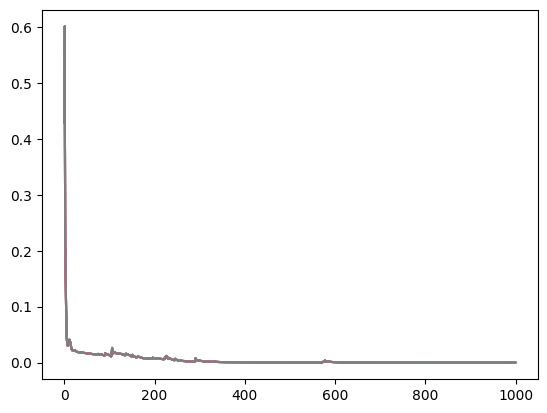

In [9]:
for i in range(8):
	plt.plot(range(1000),LossHist)

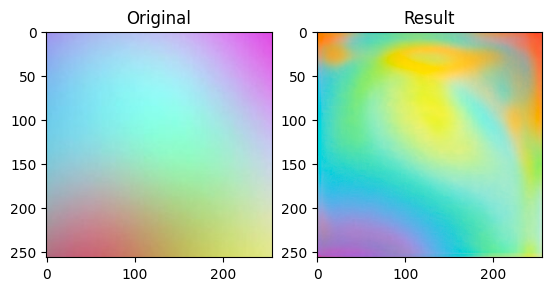

In [10]:
model.eval()
with torch.no_grad():
	TestImg = cv2.imread('Test.png')
	TestLab = cv2.cvtColor(TestImg,cv2.COLOR_BGR2LAB)
	TestInp = (torch.from_numpy(TestLab[:,:,0:1]).float()/255.0).permute(2,0,1).unsqueeze(0).to(device)
	TestOut = model(TestInp)
	TestResRaw = torch.concat((TestInp,TestOut),dim=1).squeeze(0).permute(1,2,0).cpu().detach().numpy()
	TestResNorm = np.clip((TestResRaw*255.0),0,255).astype(np.uint8)

	plt.subplot(1,2,1)
	plt.title('Original')
	plt.imshow(cv2.cvtColor(TestImg,cv2.COLOR_BGR2RGB))
	
	plt.subplot(1,2,2)
	plt.title('Result')
	plt.imshow(cv2.cvtColor(TestResNorm,cv2.COLOR_LAB2RGB))

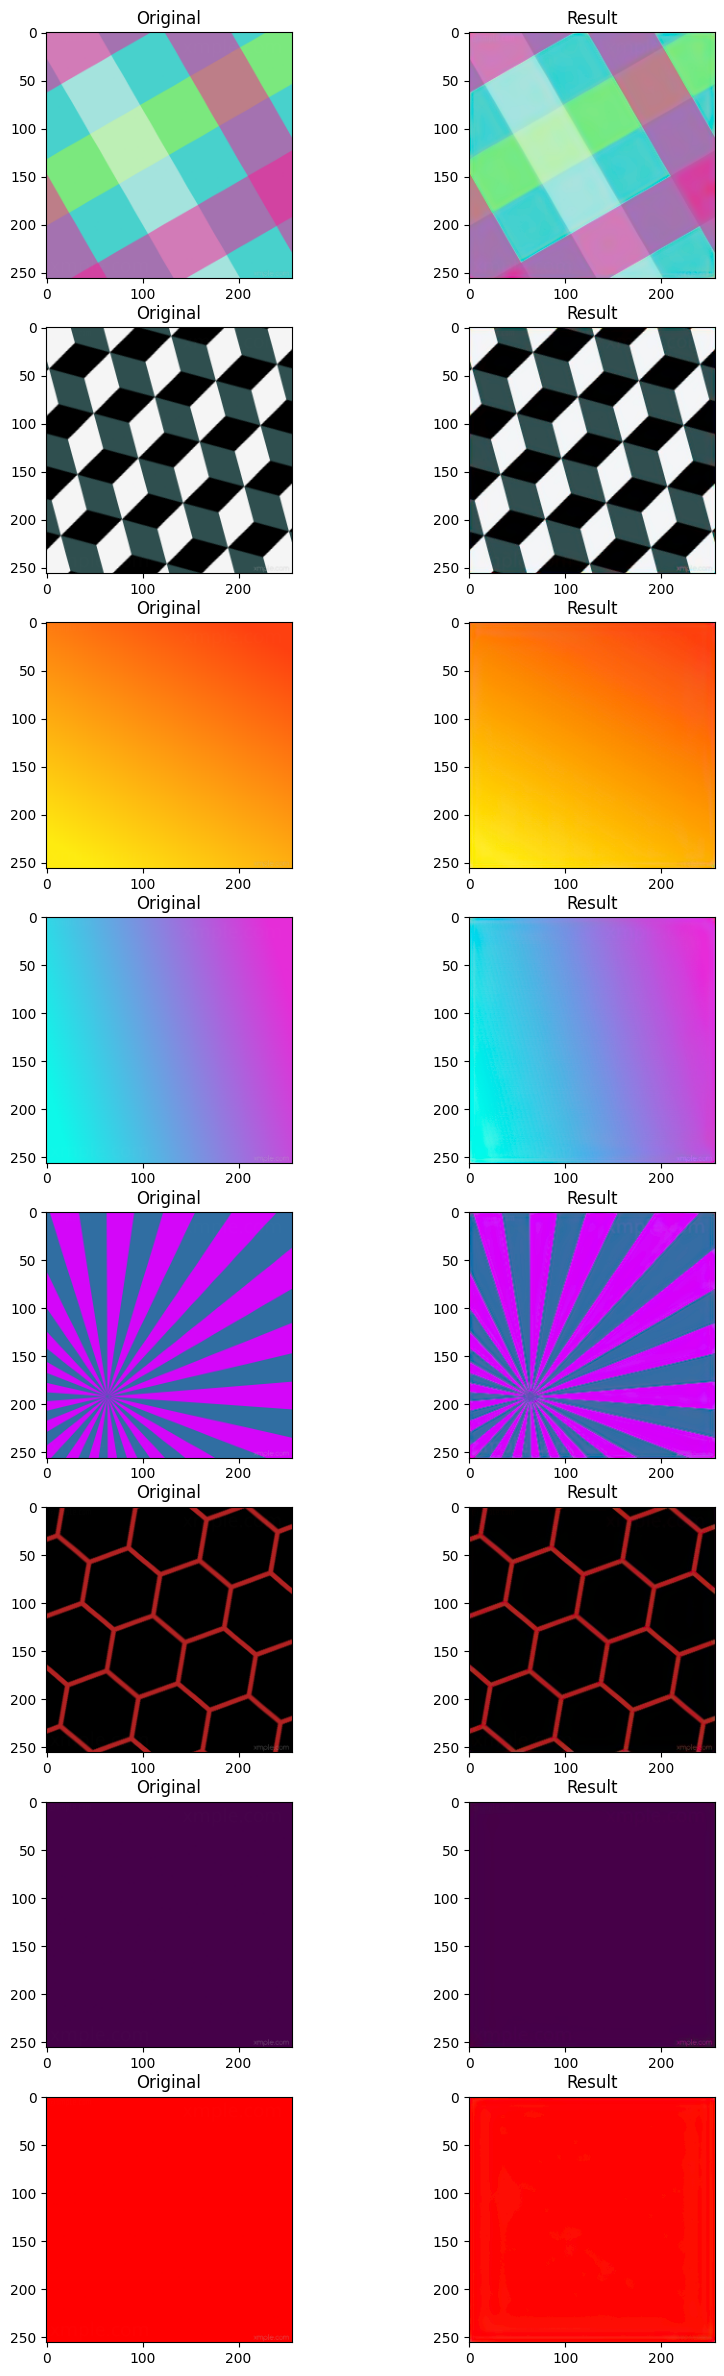

In [11]:
plt.figure(figsize=(10,30))
with torch.no_grad():
	for ImgId,ImgName in enumerate(os.listdir(ImgDirName)):
		ImgPath = os.path.join(ImgDirName,ImgName)
		if os.path.isfile(ImgPath):
			TestImg = cv2.imread(ImgPath)
			TestLab = cv2.cvtColor(TestImg,cv2.COLOR_BGR2LAB)
			TestInp = (torch.from_numpy(TestLab[:,:,0:1]).float()/255.0).permute(2,0,1).unsqueeze(0).to(device)
			TestOut = model(TestInp)
			TestResRaw = torch.concat((TestInp,TestOut),dim=1).squeeze(0).permute(1,2,0).cpu().detach().numpy()
			TestResNorm = np.clip((TestResRaw*255.0),0,255).astype(np.uint8)

			plt.subplot(8,2,(2*ImgId+1))
			plt.title('Original')
			plt.imshow(cv2.cvtColor(TestImg,cv2.COLOR_BGR2RGB))
			
			plt.subplot(8,2,(2*ImgId+2))
			plt.title('Result')
			plt.imshow(cv2.cvtColor(TestResNorm,cv2.COLOR_LAB2RGB))